
# Clasificación de Imágenes
## Transfer Learning + Fine-Tuning con **CIFAR-10** (Keras/TensorFlow)

**Objetivos de aprendizaje**
- Comprender el flujo completo de un proyecto de clasificación de imágenes.
- Implementar un modelo base **desde cero** (CNN simple) como referencia.
- Aplicar **Transfer Learning** usando un modelo preentrenado (MobileNetV2) y luego **Fine-Tuning**.
- Evaluar el desempeño con: *accuracy*, matriz de confusión, *classification report* y análisis de errores.
- Guardar y reutilizar el modelo entrenado.

> **Nota**: Al usar `weights="imagenet"` TensorFlow descargará los pesos la primera vez (requiere internet en tu entorno de ejecución).



## 1. Preparación del entorno

Instalación recomendada (si aplica):
```bash
pip install -U tensorflow scikit-learn matplotlib
```


In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

# Reproducibilidad (no absoluta en GPU, pero ayuda)
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU") != [])


TensorFlow: 2.20.0
GPU disponible: False



## 2. Carga del dataset: CIFAR-10

CIFAR-10 contiene:
- 60.000 imágenes a color (32×32)
- 10 clases (avión, auto, ave, gato, ciervo, perro, rana, caballo, barco, camión)
- Split estándar: 50.000 train / 10.000 test

**Desafío**: MobileNetV2 fue entrenado en ImageNet con tamaño 224×224.  
Aquí **reescalaremos y redimensionaremos** las imágenes.


In [ ]:

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# y vienen como shape (N,1); los aplanamos a (N,)
y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)


Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)



## 3. Exploración rápida (EDA visual)

Mostramos algunas imágenes por clase para entender variabilidad y ruido.


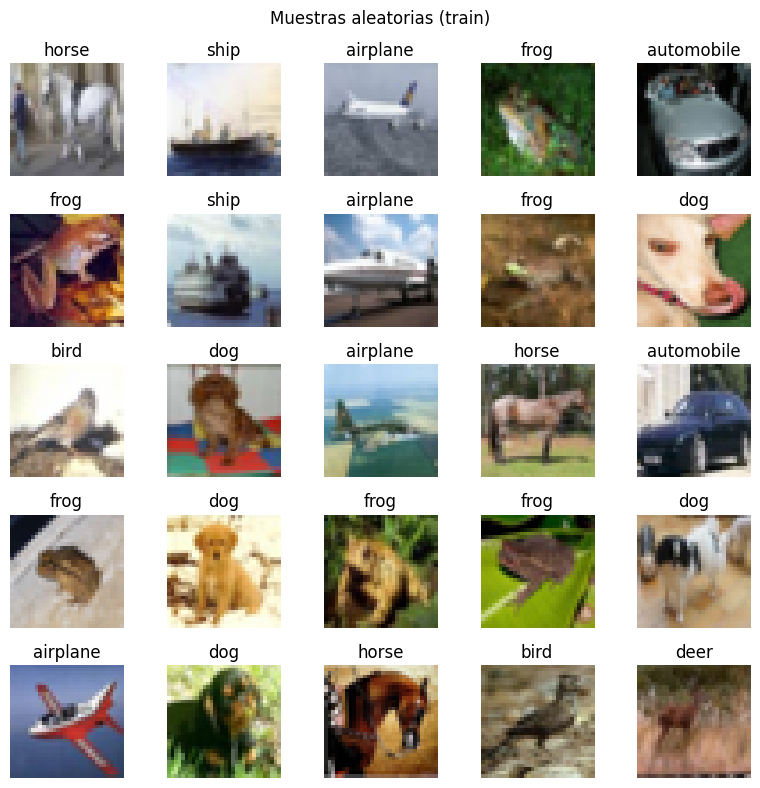

In [ ]:

def plot_grid(images, labels, n=25, title="Muestras"):
    plt.figure(figsize=(8,8))
    for i in range(n):
        ax = plt.subplot(int(np.sqrt(n)), int(np.sqrt(n)), i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

idx = np.random.choice(len(x_train), size=25, replace=False)
plot_grid(x_train[idx], y_train[idx], n=25, title="Muestras aleatorias (train)")



## 4. Split Train/Validation

Usamos parte del train para validación (por ejemplo 10%).


In [ ]:

from sklearn.model_selection import train_test_split

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=SEED, stratify=y_train
)

print("Train:", x_tr.shape, y_tr.shape)
print("Val  :", x_val.shape, y_val.shape)


Train: (45000, 32, 32, 3) (45000,)
Val  : (5000, 32, 32, 3) (5000,)



## 5. Preprocesamiento y *data pipeline*

Buenas prácticas:
- Convertir a `float32`
- Normalizar (0-1) para modelo desde cero
- Para MobileNetV2: usar `tf.keras.applications.mobilenet_v2.preprocess_input`
- Usar `tf.data` para rendimiento (cache/prefetch)

También incluimos **data augmentation** (solo en entrenamiento).


In [ ]:

BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

# Data augmentation (aplica solo en train)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

# Para CNN desde cero: normalización simple [0,1]
def preprocess_basic(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

def make_ds_basic(x, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10_000, seed=SEED)
    ds = ds.map(preprocess_basic, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
    return ds

train_ds_basic = make_ds_basic(x_tr, y_tr, training=True)
val_ds_basic   = make_ds_basic(x_val, y_val, training=False)
test_ds_basic  = make_ds_basic(x_test, y_test, training=False)

next(iter(train_ds_basic))[0].shape


2026-02-13 20:52:33.746303: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


TensorShape([64, 32, 32, 3])


## 6. Modelo baseline: CNN simple (desde cero)

Esto sirve como referencia para comparar con Transfer Learning.

Arquitectura típica:
- Conv → MaxPool (repetido)
- Flatten → Dense
- Dropout para regularización

> CIFAR-10 es un dataset desafiante: con una CNN simple deberías ver un desempeño moderado.


In [ ]:

def build_baseline_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="baseline_cnn")

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
baseline_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)


### 6.1 Entrenamiento del baseline

Usamos:
- `EarlyStopping` (evita sobreajuste)
- `ReduceLROnPlateau` (reduce LR si se estanca)

## DESAFIO
### sobreajuste
¿que herramientas se pueden aplicar para bajar o eliminar el sobreajuste?

In [ ]:

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

history_baseline = baseline_model.fit(
    train_ds_basic,
    validation_data=val_ds_basic,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.3869 - loss: 1.6770 - val_accuracy: 0.4938 - val_loss: 1.3731 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.5303 - loss: 1.3105 - val_accuracy: 0.5638 - val_loss: 1.2068 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.5928 - loss: 1.1503 - val_accuracy: 0.5992 - val_loss: 1.1288 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.6335 - loss: 1.0459 - val_accuracy: 0.6512 - val_loss: 1.0111 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.6633 - loss: 0.9587 - val_accuracy: 0.6672 - val_loss: 0.9879 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.6848 - loss: 0.8935 - val_accuracy: 0.6816 - val_loss: 0.9353 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.7088 - l


### 6.2 Curvas de aprendizaje

Graficamos loss y accuracy por época.


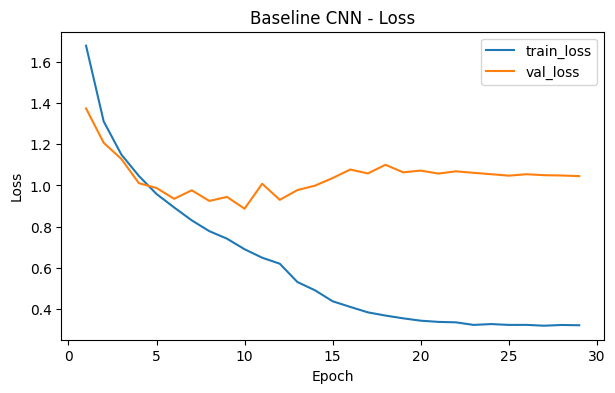

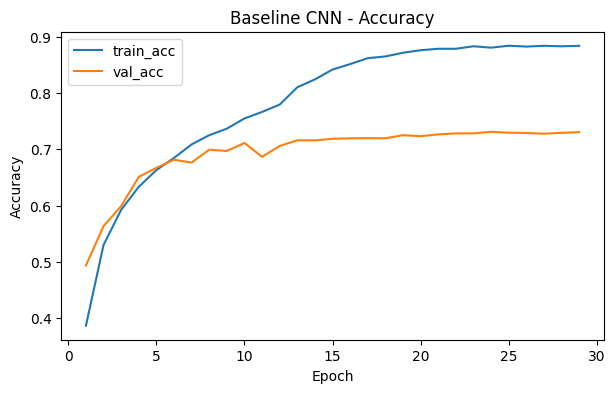

In [ ]:

def plot_history(history, title="Entrenamiento"):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(12, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["accuracy"], label="train_acc")
    plt.plot(epochs, hist["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.show()

plot_history(history_baseline, title="Baseline CNN")



### 6.3 Evaluación en test (baseline)

- Accuracy global
- Matriz de confusión
- Reporte por clase (precision/recall/F1)


In [ ]:

test_loss, test_acc = baseline_model.evaluate(test_ds_basic, verbose=0)
print(f"Baseline - Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

y_prob = baseline_model.predict(test_ds_basic, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", cm)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))


Baseline - Test loss: 1.0428 | Test acc: 0.7364
Matriz de confusión:
 [[797  30  27  13  13   2   4  12  38  64]
 [ 10 887   0   6   0   2   3   1  11  80]
 [ 75  13 571  56  81  39  84  46   7  28]
 [ 21  19  55 515  58 140  90  48  16  38]
 [ 25   6  49  48 625  24  83 118   7  15]
 [ 16   9  39 145  45 610  37  71   5  23]
 [  5  13  23  42  23  14 852   5   4  19]
 [ 17   9  17  29  33  36  13 812   0  34]
 [ 61  43   6   6   4   4   5   4 822  45]
 [ 20  71   4   5   0   3   2  12  10 873]]

Classification report:

              precision    recall  f1-score   support

    airplane       0.76      0.80      0.78      1000
  automobile       0.81      0.89      0.84      1000
        bird       0.72      0.57      0.64      1000
         cat       0.60      0.52      0.55      1000
        deer       0.71      0.62      0.66      1000
         dog       0.70      0.61      0.65      1000
        frog       0.73      0.85      0.78      1000
       horse       0.72      0.81      0.


### 6.4 Análisis de errores (baseline)

Visualizamos algunos casos mal clasificados para entender patrones:
- confusión entre clases similares (cat vs dog, deer vs horse, etc.)
- imágenes borrosas o con fondo dominante


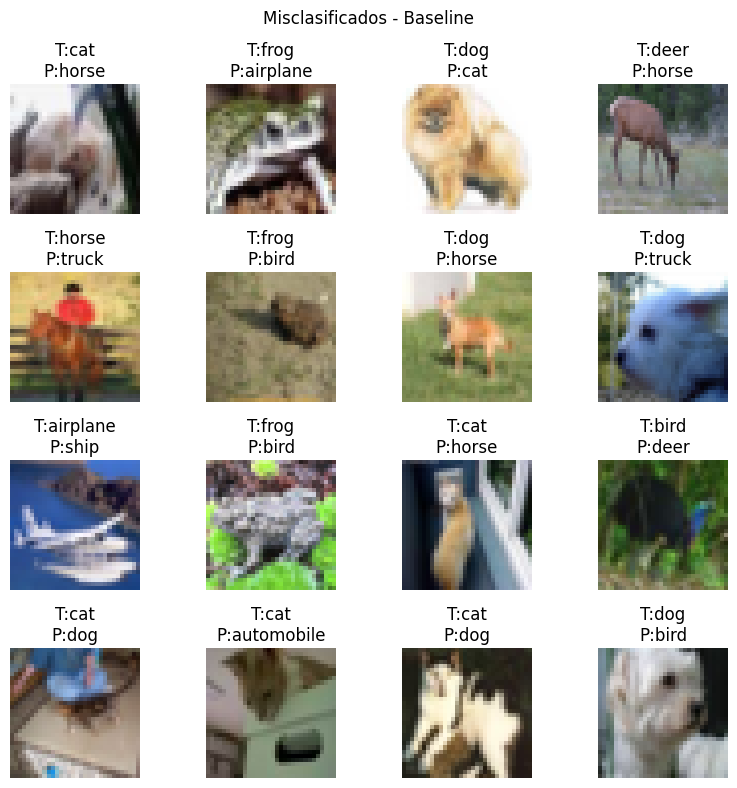

In [ ]:

def show_misclassified(x, y_true, y_pred, n=16, title="Errores"):
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        print("No hay errores para mostrar.")
        return
    pick = np.random.choice(wrong, size=min(n, len(wrong)), replace=False)

    plt.figure(figsize=(8,8))
    for i, idx in enumerate(pick):
        ax = plt.subplot(4, 4, i+1)
        plt.imshow(x[idx])
        plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_misclassified(x_test, y_test, y_pred, n=16, title="Misclasificados - Baseline")



## 7. Transfer Learning con MobileNetV2

**Idea**: reutilizar un extractor de características entrenado en ImageNet.

Pasos:
1. Redimensionar CIFAR-10 a 224×224 (requerido por MobileNetV2).
2. Aplicar `preprocess_input` específico.
3. Cargar MobileNetV2 sin la "cabeza" (`include_top=False`).
4. Congelar el modelo base.
5. Entrenar una nueva cabeza clasificadora para 10 clases.


In [ ]:

IMG_SIZE = 224

# Preprocess de MobileNetV2
preprocess_mnv2 = tf.keras.applications.mobilenet_v2.preprocess_input

resize_layer = layers.Resizing(IMG_SIZE, IMG_SIZE, name="resize")

def preprocess_mobilenet(x, y):
    x = tf.cast(x, tf.float32)
    x = resize_layer(x)
    x = preprocess_mnv2(x)  # escala a rango esperado por MobileNetV2
    return x, y

def make_ds_mobilenet(x, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10_000, seed=SEED)
    ds = ds.map(preprocess_mobilenet, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
    return ds

train_ds_tl = make_ds_mobilenet(x_tr, y_tr, training=True)
val_ds_tl   = make_ds_mobilenet(x_val, y_val, training=False)
test_ds_tl  = make_ds_mobilenet(x_test, y_test, training=False)

next(iter(train_ds_tl))[0].shape


2026-02-13 21:01:18.250447: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


TensorShape([64, 224, 224, 3])


### 7.1 Construcción del modelo (feature extraction)

- `base_model.trainable = False` congela pesos preentrenados.
- `GlobalAveragePooling2D` reduce parámetros y mejora generalización.


In [ ]:

def build_transfer_model(num_classes=10):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False  # congelado

    inputs = keras.Input(shape=(32,32,3))
    x = tf.cast(inputs, tf.float32)
    x = resize_layer(x)
    x = preprocess_mnv2(x)
    x = data_augmentation(x, training=True)  # augmentation dentro del grafo
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    return model, base_model

tl_model, base_model = build_transfer_model()
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
tl_model.summary()


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```



### 7.2 Entrenamiento (solo la cabeza)

Entrenamos pocas épocas porque la cabeza converge rápido.


In [ ]:

callbacks_tl = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6)
]

history_tl = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=callbacks_tl,
    verbose=1
)

plot_history(history_tl, title="Transfer Learning (MobileNetV2 congelado)")



### 7.3 Evaluación en test (Transfer Learning)

Comparamos contra el baseline.


In [ ]:

test_loss_tl, test_acc_tl = tl_model.evaluate(test_ds_tl, verbose=0)
print(f"Transfer (congelado) - Test loss: {test_loss_tl:.4f} | Test acc: {test_acc_tl:.4f}")

y_prob_tl = tl_model.predict(test_ds_tl, verbose=0)
y_pred_tl = np.argmax(y_prob_tl, axis=1)

cm_tl = confusion_matrix(y_test, y_pred_tl)
print("Matriz de confusión:\n", cm_tl)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_tl, target_names=class_names))

show_misclassified(x_test, y_test, y_pred_tl, n=16, title="Misclasificados - Transfer (congelado)")



## 8. Fine-Tuning (ajuste fino)

Una vez que la cabeza está razonablemente entrenada:
- Descongelamos **parte** del modelo base (capas finales)
- Entrenamos con **learning rate pequeño** para no destruir features útiles.

Regla práctica:
- Descongelar las últimas 10–30 capas (depende del dataset y tamaño)
- LR: 1e-5 o 1e-4


In [ ]:

# Descongelar parcialmente
base_model.trainable = True

# Congelar todas menos las últimas N capas
N = 30
for layer in base_model.layers[:-N]:
    layer.trainable = False

# Recompilar con LR pequeño
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=8,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)],
    verbose=1
)

plot_history(history_ft, title=f"Fine-Tuning (últimas {N} capas)")



### 8.1 Evaluación final en test (Fine-Tuning)


In [ ]:

test_loss_ft, test_acc_ft = tl_model.evaluate(test_ds_tl, verbose=0)
print(f"Fine-Tuning - Test loss: {test_loss_ft:.4f} | Test acc: {test_acc_ft:.4f}")

y_prob_ft = tl_model.predict(test_ds_tl, verbose=0)
y_pred_ft = np.argmax(y_prob_ft, axis=1)

cm_ft = confusion_matrix(y_test, y_pred_ft)
print("Matriz de confusión:\n", cm_ft)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_ft, target_names=class_names))

show_misclassified(x_test, y_test, y_pred_ft, n=16, title="Misclasificados - Fine-Tuning")



## 9. Comparación de resultados (resumen)

En general, deberías observar:
- Baseline CNN: desempeño moderado
- Transfer Learning congelado: mejora rápida
- Fine-Tuning: suele mejorar un poco más (si se ajusta correctamente)

> Nota: resultados exactos dependen de GPU/CPU, semillas, augmentations y épocas.


In [ ]:

print("Resumen de accuracies (test)")
print(f"- Baseline CNN        : {test_acc:.4f}")
print(f"- Transfer (congelado): {test_acc_tl:.4f}")
print(f"- Fine-Tuning         : {test_acc_ft:.4f}")



## 10. Guardado y reutilización del modelo

Guardamos en formato **SavedModel** (recomendado) o `.keras`.

Luego mostramos cómo cargar y hacer una predicción sobre un batch del test.


In [ ]:

EXPORT_DIR = "modelo_cifar10_transfer"
tl_model.save(EXPORT_DIR)  # guarda arquitectura + pesos + optimizer (si aplica)

# Cargar modelo
loaded = keras.models.load_model(EXPORT_DIR)

# Probar predicción rápida
batch_x, batch_y = next(iter(test_ds_tl))
probs = loaded.predict(batch_x, verbose=0)
preds = np.argmax(probs, axis=1)

print("Batch preds:", preds[:10])
print("Batch true :", batch_y.numpy()[:10])



## 11. Predicción sobre una imagen externa
Si tienes una imagen local, por ejemplo: `mi_imagen.jpg`, puedes predecirla así.

> **Importante**: CIFAR-10 tiene clases específicas y es de baja resolución. Para mejores resultados en el mundo real, usa un dataset alineado a tu dominio.


In [ ]:

# Cambia esta ruta por una imagen local (JPG/PNG)
IMG_PATH = None  # e.g. "mi_imagen.jpg"

def predict_image(path, model):
    img = keras.utils.load_img(path)  # carga con tamaño original
    arr = keras.utils.img_to_array(img)
    arr = tf.expand_dims(arr, axis=0)  # (1,H,W,3)

    # Reutilizamos el mismo pipeline: resizing + preprocess dentro del modelo
    probs = model.predict(arr, verbose=0)[0]
    pred = int(np.argmax(probs))
    return pred, probs[pred]

if IMG_PATH is not None and os.path.exists(IMG_PATH):
    pred, conf = predict_image(IMG_PATH, loaded)
    print(f"Predicción: {class_names[pred]} | confianza: {conf:.3f}")
else:
    print("Define IMG_PATH con una ruta válida para probar predicción externa.")



## 12. Checklist de buenas prácticas
- [x] EDA visual básica  
- [x] Pipeline `tf.data` con `cache/prefetch`  
- [x] Data augmentation  
- [x] Baseline desde cero (para comparar)  
- [x] Transfer learning (feature extraction)  
- [x] Fine-tuning con LR pequeño  
- [x] Métricas + matriz de confusión + reporte por clase  
- [x] Análisis de errores (misclasificados)  
- [x] Guardado y recarga del modelo  

**Ideas para extensión** (mejoras a implementar [estudiar])
- Grad-CAM (interpretabilidad)
- Mixed precision en GPU
- Ajuste de hiperparámetros (Optuna/KerasTuner)
- Regularización (label smoothing, weight decay)
